# 03 — Exploratory Data Analysis (EDA)

This notebook characterizes the **acoustic profile of each genre** and of
the two corpora (**Caribbean** vs **West African**) using the features
produced in `02_audio_feature_extraction.ipynb`.

**What this notebook does, in order:**
1. Loads `data/processed/features.csv` and prepares a clean numeric feature set.
3. Computes descriptive statistics (mean, std, skewness) per feature, grouped by genre and corpus.
4. The Normality Test, Shapiro-Wilk was used to determine parametric or non-parametric stats per feature.
5. Creates KDE (Kernel Density Estimation) Density Plots to determine the overlaid distributions for Caribbean vs West African. 
6. Creates Box plots and Violin plots for inter-group comparison.
7. Creates Chroma / Pitch Profiles to compare pitch-class usage between corpora.
9. Group-level mean-feature heatmaps (z-scored).
10. Reduces features to 2D via PCA (Principal Component Analysis) and see if tracks cluster by tradition.
11. Rnk features by Cohen's d to identify which most distinguish Caribbean from West African music.
12. Flags and removes near-zero-variance features.

## 1. Imports and Setup

- `pandas` / `numpy` — data handling
- `scipy.stats` — skewness, normality tests, Pearson/Spearman correlation
- `sklearn` — PCA and standardization
- `matplotlib` / `seaborn` — all plots

In [118]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import ast
import re
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# ── Colour palette ───────────────────────────────────────────────────────────
# Two-corpus palette used consistently throughout
CORPUS_PALETTE = {"caribbean": "#2196F3", "west_african": "#FF9800"}

# Genre palette (6 Caribbean + West African as one group)
GENRE_PALETTE = sns.color_palette("tab10", 10)

## 2. Load `features.csv`

In [119]:
FEATURES_PATH = Path("../data/processed/features.csv")

df = pd.read_csv(FEATURES_PATH)


CORPUS_COLORS = ["#2196F3", "#FF9800"]   # blue = corpus 1, orange = corpus 2

corpus_values = sorted(df["corpus"].dropna().unique())
CORPUS_PALETTE = {name: CORPUS_COLORS[i % len(CORPUS_COLORS)]
                  for i, name in enumerate(corpus_values)}

print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
print(f"Corpus values detected: {corpus_values}")
print(f"Corpus palette: {CORPUS_PALETTE}")
df.head()

Loaded 364 rows, 40 columns
Corpus values detected: ['caribbean', 'westafrica']
Corpus palette: {'caribbean': '#2196F3', 'westafrica': '#FF9800'}


,track_id,genre,corpus,file_path,chroma_mean,estimated_key,mode,key_correlation,tempo_bpm,beat_count,mean_ibi_sec,ibi_std_sec,mean_beat_strength,rms_mean,rms_std,lufs_integrated,dynamic_range_db,spectral_centroid_mean,spectral_bandwidth_mean,spectral_flux_mean,log_attack_time_ms,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,onsets_per_second,textural_grain_mean,ssm_shape,ssm_mean_affinity,segment_boundary_times,segment_count
0,1maQdXRvqcu58cRPJGPZDC,compas,caribbean,../data/raw/audio/compas/1maQdXRvqcu58cRPJGPZD...,"[0.4399217665195465, 0.30649739503860474, 0.63...",G,minor,0.602693,129.199219,62,0.481909,0.043827,5.093007,0.288713,0.184072,-11.604260,115.007805,1572.734830,1859.525176,1.223082,35.646259,-87.904556,111.895248,-4.389726,21.172777,2.724747,6.457137,-1.804952,0.930845,-1.210105,-2.029106,-6.834020,-6.702654,-8.586039,3.300000,0.006143,"[1292, 1292]",0.021349,"[0.0, 1.3003174603174603, 2.2523356009070294, ...",5
1,7fQLUCOYcafUT9ZppkUjCj,compas,caribbean,../data/raw/audio/compas/7fQLUCOYcafUT9ZppkUjC...,"[0.4287168085575104, 0.6749270558357239, 0.552...",C#,major,0.444137,117.453835,59,0.505635,0.020244,4.205979,0.296260,0.097006,-10.811777,26.078304,2838.903009,2854.513721,1.455910,31.428571,-2.708890,79.383072,7.509683,5.906637,6.428209,2.082538,-0.200764,5.286302,-7.552994,7.566379,0.560632,-0.393011,-0.640991,4.633333,0.034319,"[1292, 1292]",0.017316,"[0.0, 0.8591383219954648, 5.688888888888889, 1...",5
2,5vy8UHH3N8G7gJeKdMZhto,compas,caribbean,../data/raw/audio/compas/5vy8UHH3N8G7gJeKdMZht...,"[0.7183013558387756, 0.3741459846496582, 0.250...",F,minor,0.634376,129.199219,61,0.468269,0.014787,4.702587,0.109785,0.043355,-18.904190,31.918800,3052.200813,3097.931960,1.424877,103.265306,-129.563461,67.290962,28.077904,18.867994,16.043295,12.841761,0.181420,-0.292021,-8.977023,1.126917,-6.678824,0.375193,-8.027571,5.500000,0.022839,"[1292, 1292]",0.019571,"[0.0, 0.9752380952380952, 1.9040362811791383, ...",5
3,5gdTDWskPEc1QlJ4mukqBd,compas,caribbean,../data/raw/audio/compas/5gdTDWskPEc1QlJ4mukqB...,"[0.38055887818336487, 0.37088555097579956, 0.3...",F,minor,0.389202,129.199219,62,0.471632,0.016033,4.573918,0.302120,0.232205,-11.699441,31.856556,1458.130485,1695.578747,1.480064,79.229025,-124.806740,132.229050,-28.077898,-2.273903,-1.998060,-5.319057,8.310647,-4.012506,-13.020327,23.587822,-0.729799,-2.891400,-0.420700,4.433333,0.004706,"[1292, 1292]",0.017770,"[0.0, 0.3947392290249433, 3.575873015873016, 8...",5
4,4hMEtRcqIwQN236DnzSJ9D,compas,caribbean,../data/raw/audio/compas/4hMEtRcqIwQN236DnzSJ9...,"[0.722180187702179, 0.40799015760421753, 0.293...",F,minor,0.731417,95.703125,47,0.631482,0.015778,5.678311,0.183656,0.084785,-15.637932,25.710756,2036.687040,2317.823089,1.669622,41.043084,-115.426842,111.935852,6.014124,15.042397,13.317602,-4.839952,-5.423968,0.096804,-19.452791,5.570528,-14.138847,-5.146482,-2.423803,4.233333,0.014572,"[1292, 1292]",0.019399,"[0.0, 4.272471655328798, 8.962902494331066, 12...",5


## 3. Prepare the Feature Set

- `chroma_mean` is stored as a stringified list of 12 values (one per pitch class C to B). We unpack it into 12 separate columns so each can be compared across groups.
- `segment_boundary_times` is a variable-length list — not comparable across tracks, so we keep only `segment_count` (the scalar length of that list).
- `ssm_shape` is an audio-length artifact, not a real feature — dropped.

In [94]:
def parse_list_col(series):
    """Parse a column of stringified lists into a 2D array.
    Handles plain literal lists as well as the numpy>=2.0 repr format."""
    def _parse(x):
        if isinstance(x, str):
            cleaned = re.sub(r"np\.\w+\(([^()]+)\)", r"\1", x)
            return ast.literal_eval(cleaned)
        return x
    return series.apply(_parse)

# ── Unpack chroma_mean → 12 pitch-class columns ───────────────────────────────
PITCH_CLASSES = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

if "chroma_mean" in df.columns:
    chroma_parsed = parse_list_col(df["chroma_mean"])
    chroma_df = pd.DataFrame(
        chroma_parsed.tolist(),
        columns=[f"chroma_{pc}" for pc in PITCH_CLASSES],
        index=df.index
    )
    df = pd.concat([df, chroma_df], axis=1)

DROP_COLS = ["chroma_mean", "segment_boundary_times", "ssm_shape"]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

id_cols = [c for c in ["track_id", "file_path", "genre", "corpus", "estimated_key", "mode"] if c in df.columns]
numeric_cols = [c for c in df.columns if c not in id_cols]
numeric_cols = [c for c in numeric_cols if pd.api.types.is_numeric_dtype(df[c])]

print(f"{len(numeric_cols)} numeric feature columns ready for analysis.")
print(numeric_cols)

43 numeric feature columns ready for analysis.
['key_correlation', 'tempo_bpm', 'beat_count', 'mean_ibi_sec', 'ibi_std_sec', 'mean_beat_strength', 'rms_mean', 'rms_std', 'lufs_integrated', 'dynamic_range_db', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_flux_mean', 'log_attack_time_ms', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_4_mean', 'mfcc_5_mean', 'mfcc_6_mean', 'mfcc_7_mean', 'mfcc_8_mean', 'mfcc_9_mean', 'mfcc_10_mean', 'mfcc_11_mean', 'mfcc_12_mean', 'mfcc_13_mean', 'onsets_per_second', 'textural_grain_mean', 'ssm_mean_affinity', 'segment_count', 'chroma_C', 'chroma_C#', 'chroma_D', 'chroma_D#', 'chroma_E', 'chroma_F', 'chroma_F#', 'chroma_G', 'chroma_G#', 'chroma_A', 'chroma_A#', 'chroma_B']


## 4. Descriptive Statistics by Genre and by Corpus

For every numeric feature, we compute mean, standard deviation, and skewness — grouped by `genre` (8 groups) and by `corpus` (2 groups).

**Skewness** tells us if a feature is symmetrically distributed (skew ≈ 0), right-tailed (skew > 1) or left-tailed (skew < -1). Highly skewed features may need log-transformation before statistical tests.

In [95]:
def group_descriptive_stats(df, group_col, feature_cols):
    rows = []
    for group_val, sub in df.groupby(group_col):
        for col in feature_cols:
            vals = sub[col].dropna()
            if len(vals) == 0:
                continue
            rows.append({
                group_col: group_val,
                "feature": col,
                "mean": vals.mean(),
                "std": vals.std(),
                "skew": stats.skew(vals) if len(vals) > 2 else np.nan,
                "n": len(vals)
            })
    return pd.DataFrame(rows)

genre_stats = group_descriptive_stats(df, "genre", numeric_cols)
corpus_stats = group_descriptive_stats(df, "corpus", numeric_cols)

print("Genre-level stats (first 10 rows):")
display(genre_stats.head(10))

print("\nCorpus-level stats (first 10 rows):")
display(corpus_stats.head(10))

Genre-level stats (first 10 rows):


,genre,feature,mean,std,skew,n
0,afrobeats,key_correlation,0.649562,0.145933,-0.361199,30
1,afrobeats,tempo_bpm,115.842931,14.704408,0.803346,30
2,afrobeats,beat_count,56.166667,6.833403,0.708920,30
3,afrobeats,mean_ibi_sec,0.527187,0.060405,-0.310516,30
4,afrobeats,ibi_std_sec,0.026985,0.012282,0.468951,30
5,afrobeats,mean_beat_strength,6.888525,1.416685,-0.062645,30
6,afrobeats,rms_mean,0.237271,0.068774,-0.562801,30
7,afrobeats,rms_std,0.107791,0.030688,-0.387604,30
8,afrobeats,lufs_integrated,-13.813399,3.106882,-1.689997,30
9,afrobeats,dynamic_range_db,40.508440,35.781603,3.215831,30



Corpus-level stats (first 10 rows):


,corpus,feature,mean,std,skew,n
0,caribbean,key_correlation,0.641125,0.147681,-0.181268,245
1,caribbean,tempo_bpm,125.731796,22.718082,0.292909,245
2,caribbean,beat_count,60.808163,11.726386,0.229549,245
3,caribbean,mean_ibi_sec,0.493463,0.092094,0.746906,245
4,caribbean,ibi_std_sec,0.020258,0.009160,0.784277,245
5,caribbean,mean_beat_strength,6.549175,2.185020,1.439753,245
6,caribbean,rms_mean,0.231377,0.076900,-0.412381,245
7,caribbean,rms_std,0.086183,0.030871,1.026841,245
8,caribbean,lufs_integrated,-13.926802,3.284002,-1.338699,245
9,caribbean,dynamic_range_db,38.117968,30.634177,3.542867,245


In [96]:
# ── Pivot table: Caribbean vs West African side-by-side for key features ──────
# These 8 features map directly to the UK curriculum dimensions
KEY_FEATURES = [
    "tempo_bpm",            # Tempo dimension
    "mean_ibi_sec",         # Duration / rhythm
    "beat_count",           # Duration / rhythm
    "rms_mean",             # Dynamics
    "lufs_integrated",      # Dynamics
    "dynamic_range_db",     # Dynamics
    "spectral_centroid_mean", # Timbre
    "key_correlation"       # Pitch / tonality
]

# Filter to only features that exist in the dataset
KEY_FEATURES = [f for f in KEY_FEATURES if f in numeric_cols]

pivot = corpus_stats[corpus_stats["feature"].isin(KEY_FEATURES)].pivot(
    index="feature", columns="corpus", values=["mean", "std"]
).round(3)

display(pivot)

mean                  std           
corpus                 caribbean westafrica caribbean westafrica
feature                                                         
beat_count                60.808     57.378    11.726      9.255
dynamic_range_db          38.118     43.659    30.634     40.845
key_correlation            0.641      0.648     0.148      0.150
lufs_integrated          -13.927    -15.110     3.284      3.827
mean_ibi_sec               0.493      0.516     0.092      0.079
rms_mean                   0.231      0.205     0.077      0.081
spectral_centroid_mean  2453.999   2129.534   445.184    600.705
tempo_bpm                125.732    118.980    22.718     18.321

In [97]:
# ── Mean per feature per genre (all 7 genres) ─────────────────────────────────
pivot_genre = genre_stats[genre_stats["feature"].isin(KEY_FEATURES)].pivot(
    index="feature", columns="genre", values="mean"
).round(3)
pivot_genre.columns.name = None
pivot_genre.index.name = "Feature"
display(pivot_genre)

,afrobeats,calypso_soca,compas,highlife,juju,kora,reggae_dancehall,zouk
Feature,,,,,,,,
beat_count,56.167,58.893,61.754,54.467,59.172,59.767,65.027,54.842
dynamic_range_db,40.508,34.344,35.860,54.111,40.823,39.100,46.261,32.881
key_correlation,0.650,0.594,0.657,0.624,0.594,0.721,0.662,0.668
lufs_integrated,-13.813,-12.326,-14.955,-14.951,-14.969,-16.703,-14.405,-14.600
mean_ibi_sec,0.527,0.504,0.486,0.534,0.498,0.506,0.464,0.542
rms_mean,0.237,0.275,0.209,0.196,0.207,0.180,0.215,0.212
spectral_centroid_mean,2336.712,2576.123,2308.330,2215.509,2229.862,1739.396,2458.036,2423.499
tempo_bpm,115.843,121.830,127.279,114.170,122.341,123.678,134.429,113.945


## 5. Normality Testing — Shapiro-Wilk

- If a feature is **normally distributed** → use parametric tests (t-test, ANOVA).
- If a feature is **not normally distributed** → use non-parametric tests (Mann-Whitney U, Kruskal-Wallis).

**Shapiro-Wilk** tests whether a sample could plausibly come from a normal distribution. A p-value below 0.05 means we reject normality.

In [98]:
# ── Run Shapiro-Wilk per feature per corpus ───────────────────────────────────
normality_results = []

for corpus_name, sub in df.groupby("corpus"):
    for col in numeric_cols:
        vals = sub[col].dropna().values
        # Shapiro-Wilk is reliable for n < 5000; for larger samples use D'Agostino
        if len(vals) < 3:
            continue
        if len(vals) <= 5000:
            stat, p = stats.shapiro(vals)
            test_used = "shapiro-wilk"
        else:
            stat, p = stats.normaltest(vals)  # D'Agostino-Pearson for large n
            test_used = "dagostino-pearson"

        normality_results.append({
            "corpus": corpus_name,
            "feature": col,
            "test": test_used,
            "statistic": round(stat, 4),
            "p_value": round(p, 4),
            "is_normal": p >= 0.05  # True = likely normal, False = non-normal
        })

normality_df = pd.DataFrame(normality_results)

# Summary: how many features are normal per corpus?
summary = normality_df.groupby("corpus")["is_normal"].value_counts().unstack(fill_value=0)
print("Normality Summary (True = passes normality test at p>=0.05):")
display(summary)

# Show only features that ARE normal in both corpora — these allow parametric tests
normal_in_both = normality_df.groupby("feature")["is_normal"].all()
parametric_safe = normal_in_both[normal_in_both].index.tolist()
non_parametric_required = normal_in_both[~normal_in_both].index.tolist()

print(f"\n {len(parametric_safe)} features are normal in both corpora → parametric tests OK")
print(f"  {len(non_parametric_required)} features are non-normal in at least one corpus → use non-parametric tests")
print("\nNon-normal features (use Mann-Whitney U / Kruskal-Wallis):")
print(non_parametric_required)

Normality Summary (True = passes normality test at p>=0.05):


is_normal,False,True
corpus,,
caribbean,28,15
westafrica,17,26



 13 features are normal in both corpora → parametric tests OK
  30 features are non-normal in at least one corpus → use non-parametric tests

Non-normal features (use Mann-Whitney U / Kruskal-Wallis):
['beat_count', 'chroma_A#', 'chroma_B', 'chroma_C#', 'chroma_D', 'chroma_D#', 'chroma_E', 'chroma_F', 'chroma_G#', 'dynamic_range_db', 'ibi_std_sec', 'log_attack_time_ms', 'lufs_integrated', 'mean_beat_strength', 'mean_ibi_sec', 'mfcc_10_mean', 'mfcc_12_mean', 'mfcc_13_mean', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_5_mean', 'mfcc_7_mean', 'mfcc_9_mean', 'rms_mean', 'rms_std', 'spectral_bandwidth_mean', 'spectral_centroid_mean', 'tempo_bpm', 'textural_grain_mean']


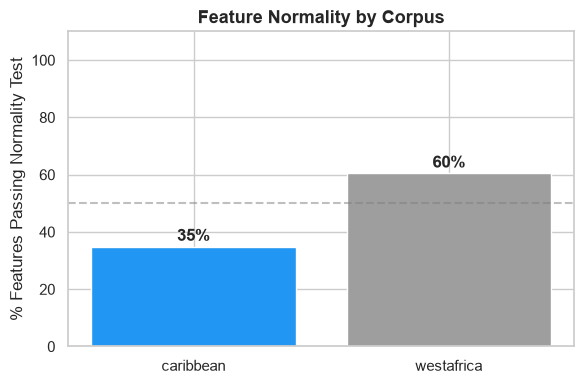

In [99]:
# ── Visual: % of features that are non-normal per corpus ─────────────────────
# This gives a quick visual summary of how 'messy' each corpus's features are
pct_normal = normality_df.groupby("corpus")["is_normal"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(pct_normal.index, pct_normal.values,
              color=[CORPUS_PALETTE.get(c, "#9E9E9E") for c in pct_normal.index])
ax.set_ylim(0, 110)
ax.set_ylabel("% Features Passing Normality Test")
ax.set_title("Feature Normality by Corpus", fontsize=13, fontweight="bold")
ax.axhline(50, color="gray", linestyle="--", alpha=0.5, label="50% line")
for bar, val in zip(bars, pct_normal.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f"{val:.0f}%",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. KDE Density Plots — Caribbean vs West African

**Kernel Density Estimation (KDE)** shows the full shape of a feature's distribution, not just its median and quartiles. When you overlay Caribbean (blue) and West African (orange) distributions on the same plot, you can immediately see:
- **Overlap** → the two traditions share similar values for this feature.
- **Separation** → the distributions barely overlap → this feature distinguishes the two traditions.

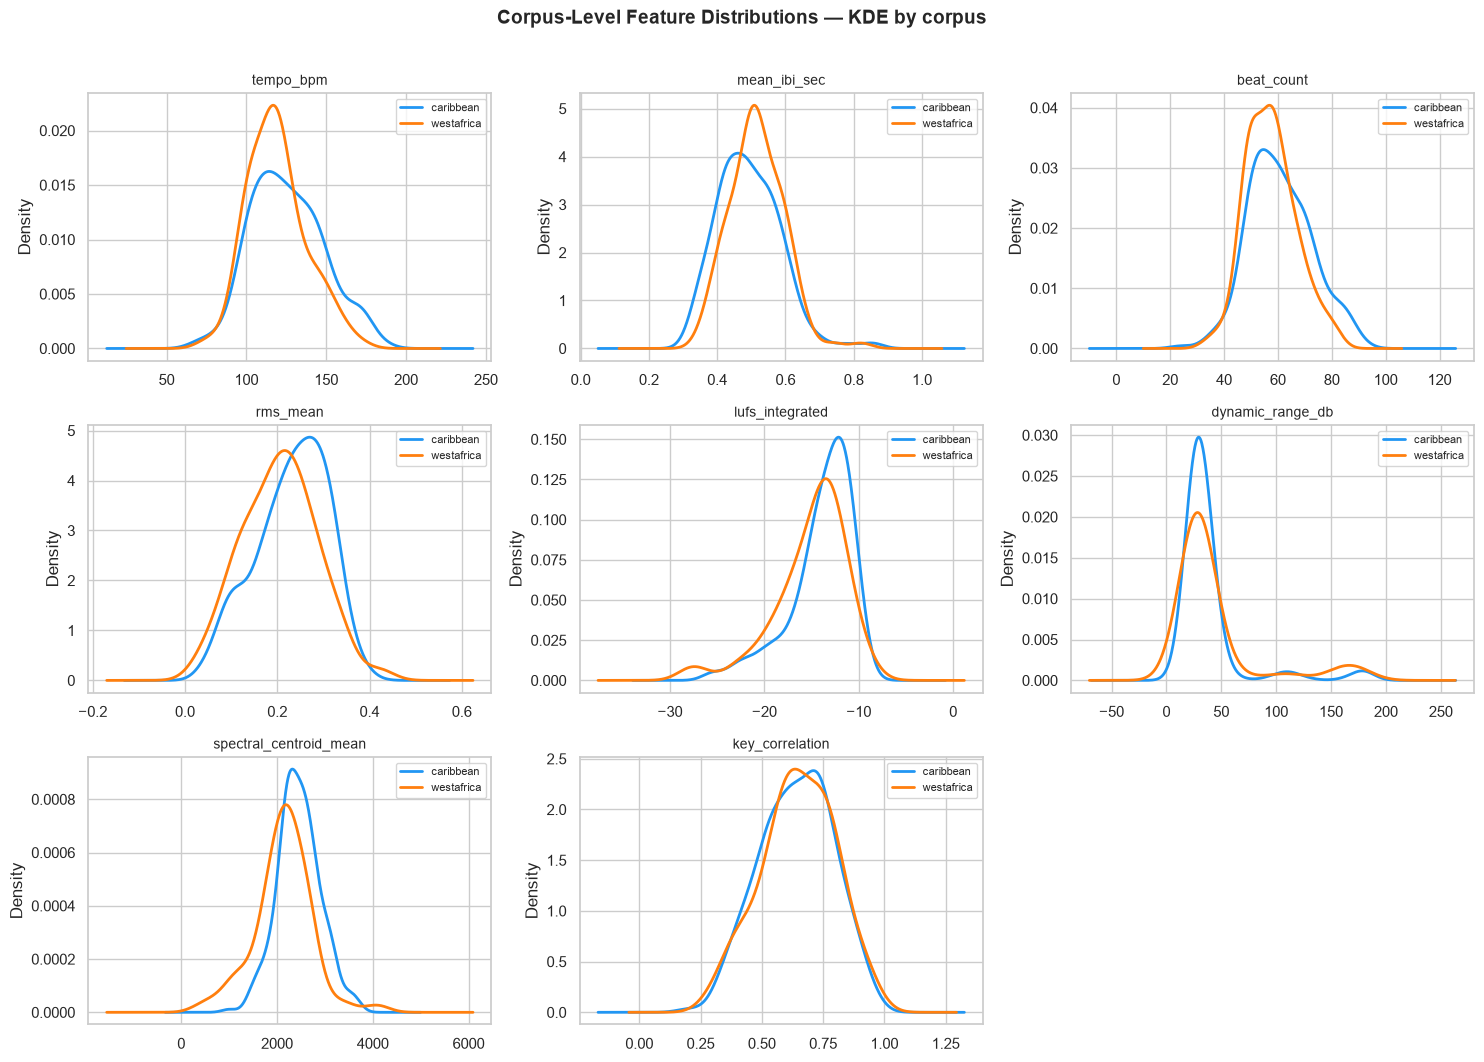

In [100]:
def kde_grid(df, group_col, feature_cols, palette, n_cols=3, title_prefix=""):
    """
    Plot overlaid KDE curves for each feature, one curve per group.
    Overlap = similarity. Separation = distinction.
    """
    groups = df[group_col].unique()
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_cols):
        ax = axes[i]
        for j, group_val in enumerate(groups):
            vals = df.loc[df[group_col] == group_val, col].dropna()
            color = palette.get(group_val, GENRE_PALETTE[j]) if isinstance(palette, dict) else GENRE_PALETTE[j]
            vals.plot.kde(ax=ax, label=str(group_val), color=color, linewidth=2)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("")
        ax.legend(fontsize=8)

    for j in range(len(feature_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{title_prefix} — KDE by {group_col}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

# Plot KDEs for key features, grouped by corpus
kde_grid(df, "corpus", KEY_FEATURES, CORPUS_PALETTE,
         title_prefix="Corpus-Level Feature Distributions")

## 7. Box Plots — Inter-Genre and Inter-Corpus Distributions

Box plots are best for spotting median shifts and outliers across groups. We plot both corpus-level (2 groups) and genre-level (all genres).

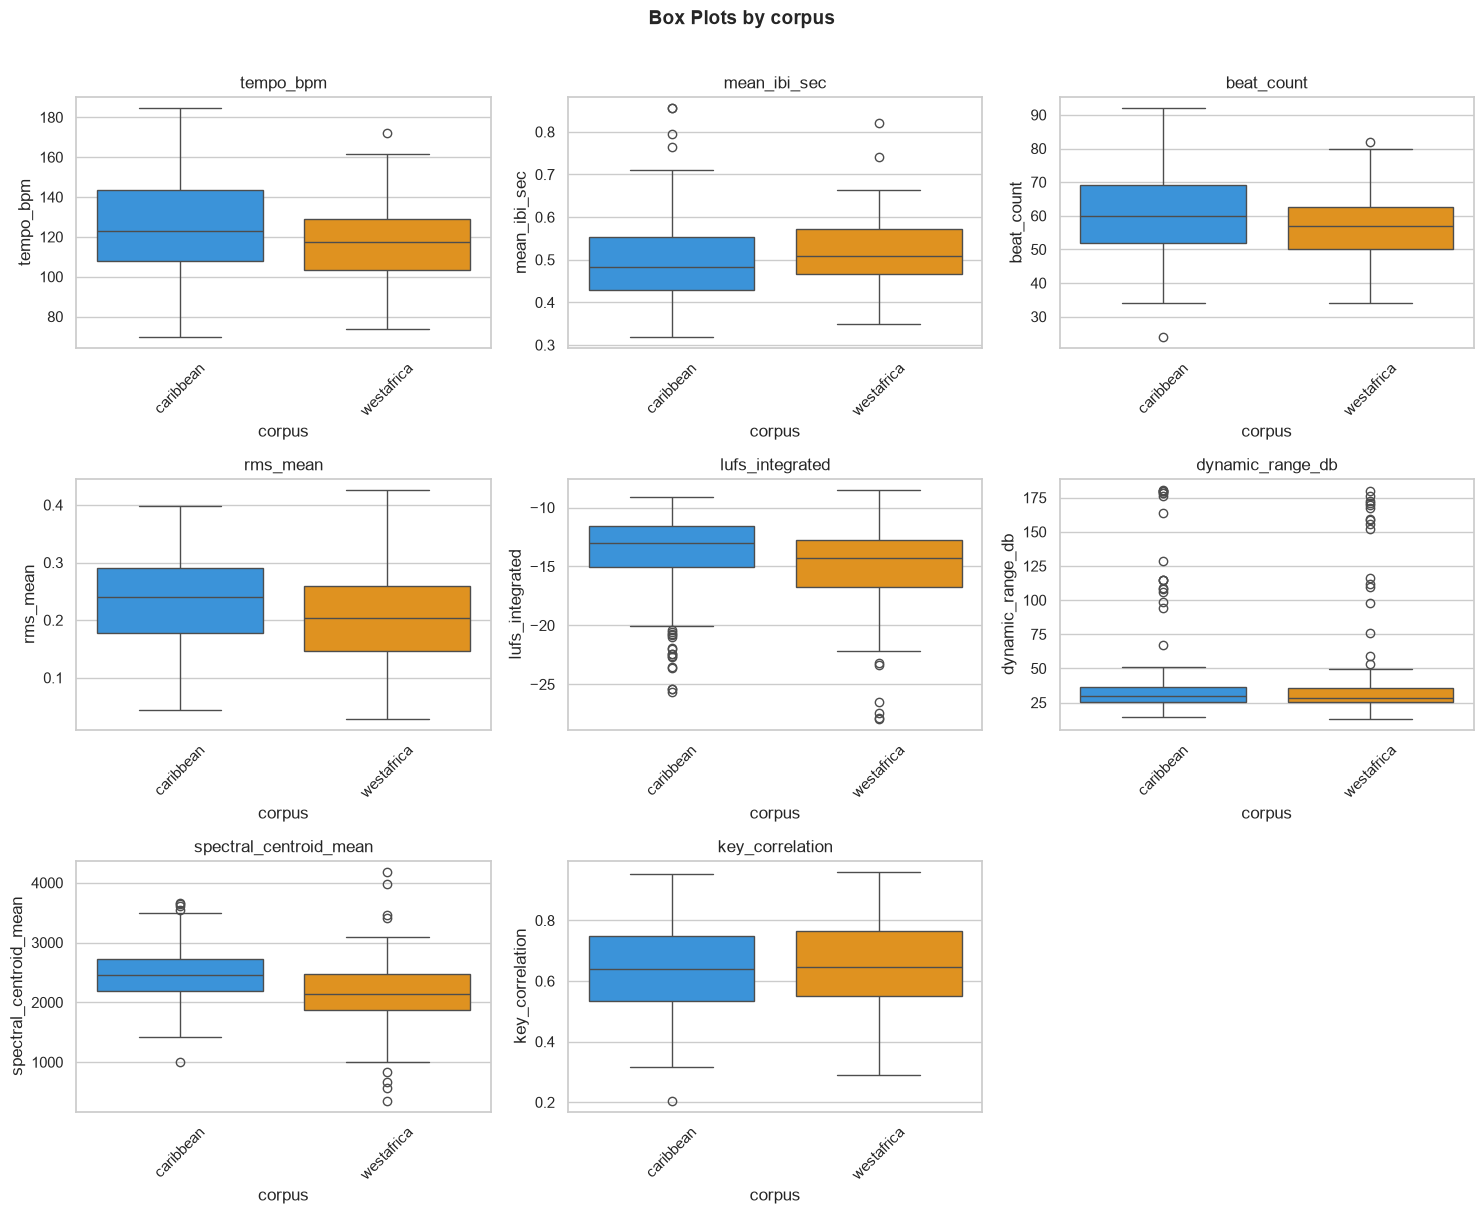

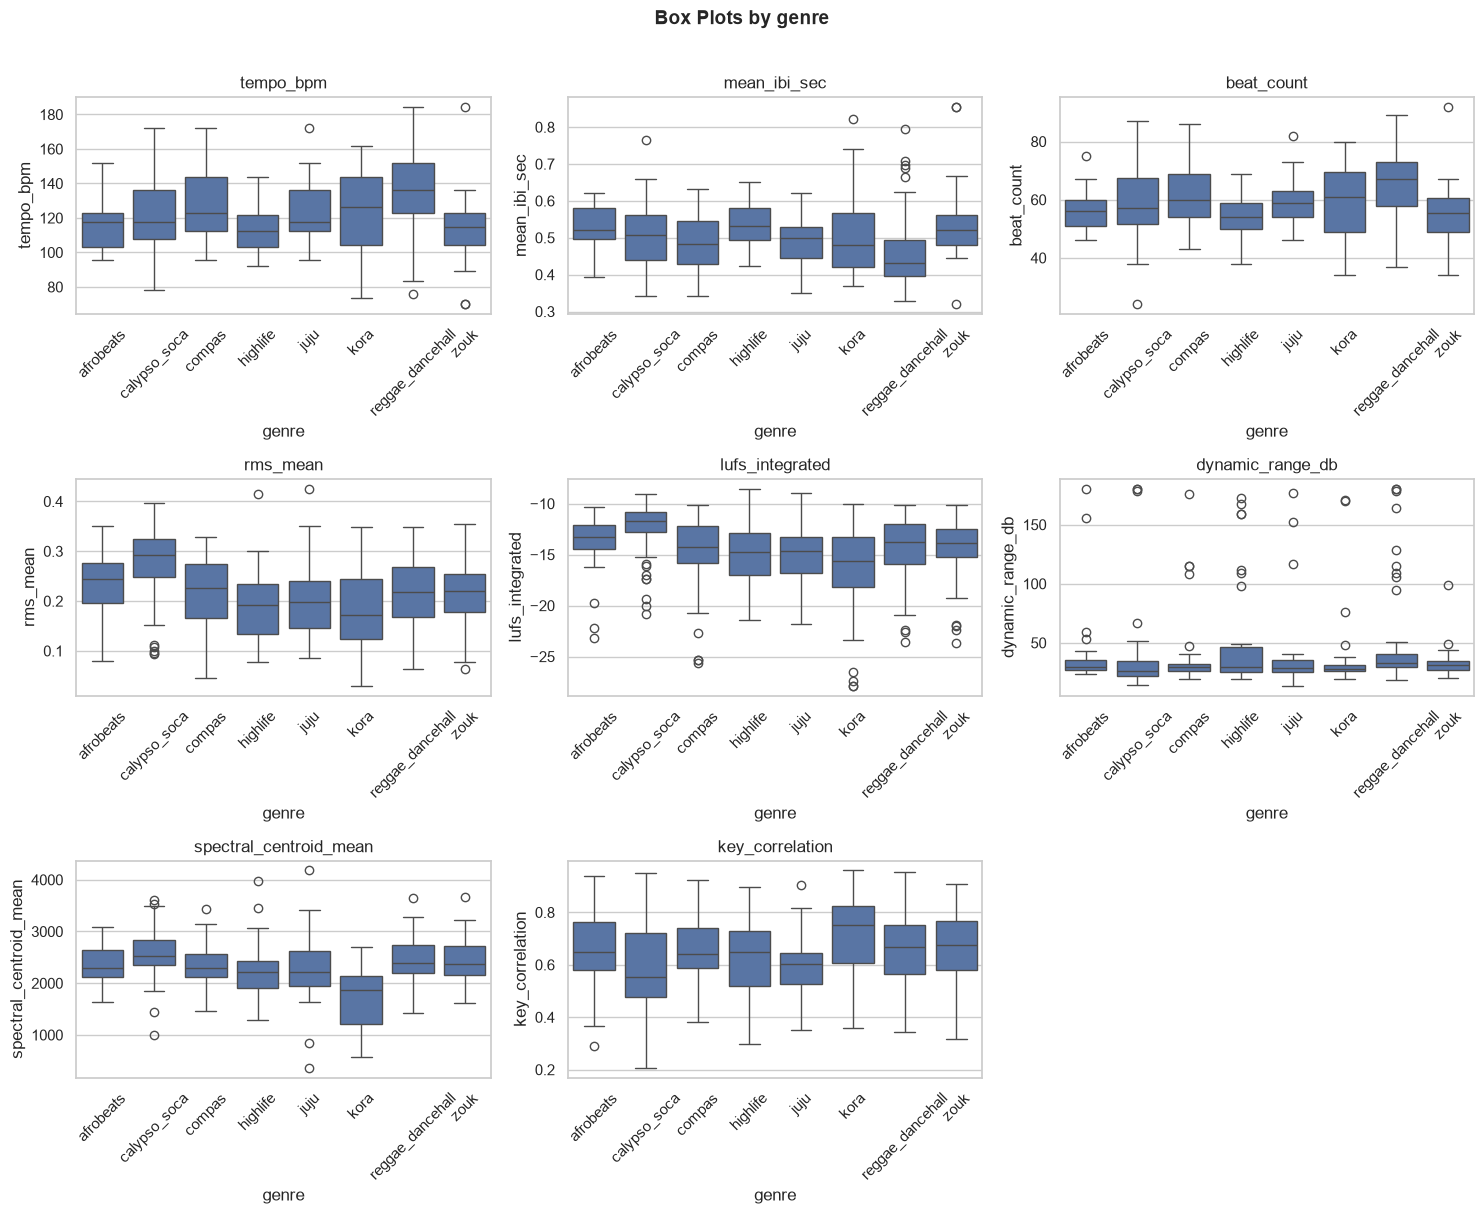

In [120]:
def boxplot_grid(df, group_col, feature_cols, palette=None, n_cols=3):
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_cols):
        sns.boxplot(data=df, x=group_col, y=col, ax=axes[i],
                    palette=palette, order=sorted(df[group_col].unique()))
        axes[i].set_title(col)
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(len(feature_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Box Plots by {group_col}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

# Corpus-level (2 groups)
boxplot_grid(df, "corpus", KEY_FEATURES, palette=CORPUS_PALETTE)

# Genre-level (all 7 genres)
boxplot_grid(df, "genre", KEY_FEATURES)

## 8. Violin Plots — Distribution Shape by Group

Violin plots add density-shape information — they help spot bimodal or skewed distributions that a box plot alone would hide (e.g. a genre with two distinct tempo 'modes').

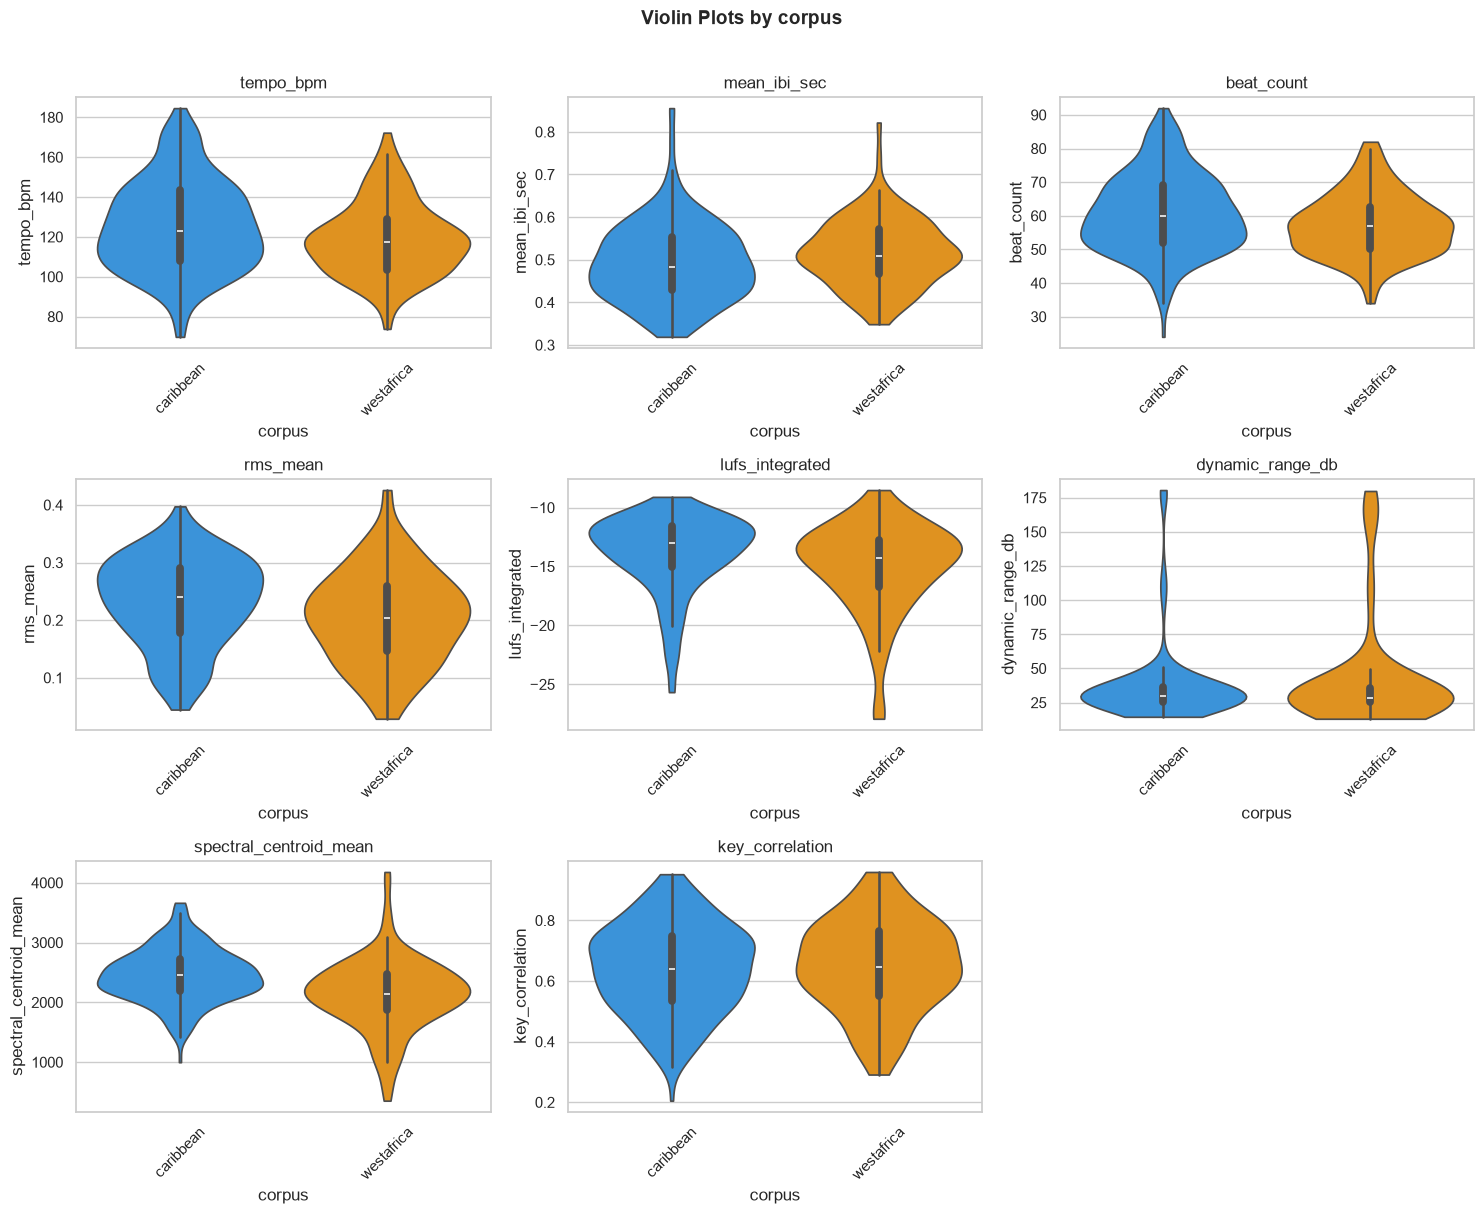

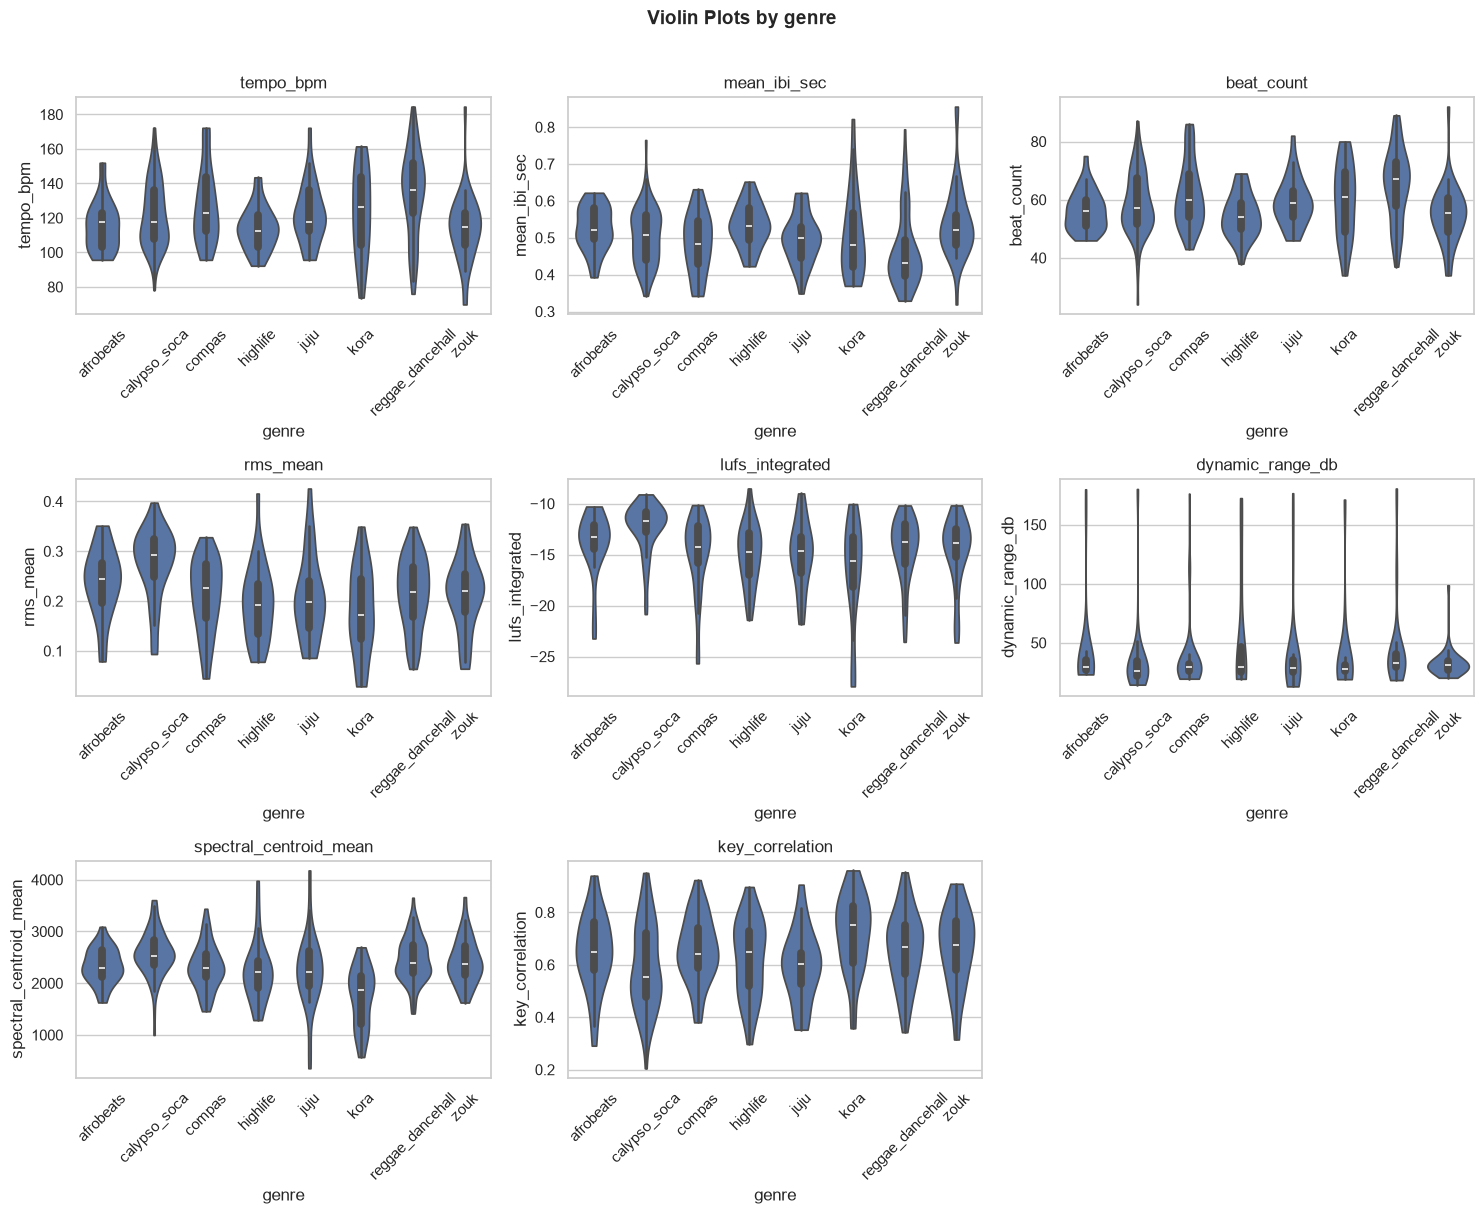

In [121]:
def violinplot_grid(df, group_col, feature_cols, palette=None, n_cols=3):
    n_rows = int(np.ceil(len(feature_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(feature_cols):
        sns.violinplot(data=df, x=group_col, y=col, ax=axes[i], cut=0,
                       palette=palette, order=sorted(df[group_col].unique()))
        axes[i].set_title(col)
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(len(feature_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Violin Plots by {group_col}", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

violinplot_grid(df, "corpus", KEY_FEATURES, palette=CORPUS_PALETTE)
violinplot_grid(df, "genre", KEY_FEATURES)

## 9. Chroma / Pitch Profile Analysis

Chroma features capture **pitch-class energy** — how much each of the 12 musical notes (C, C#, D ... B) is present in a track.

By comparing the mean chroma profile of Caribbean vs West African music, we can see:
- Do both traditions emphasize the same notes/scales?
- Are there consistent tonal differences in pitch-class usage?

The radar (spider) chart gives an intuitive circular view — one axis per pitch class.

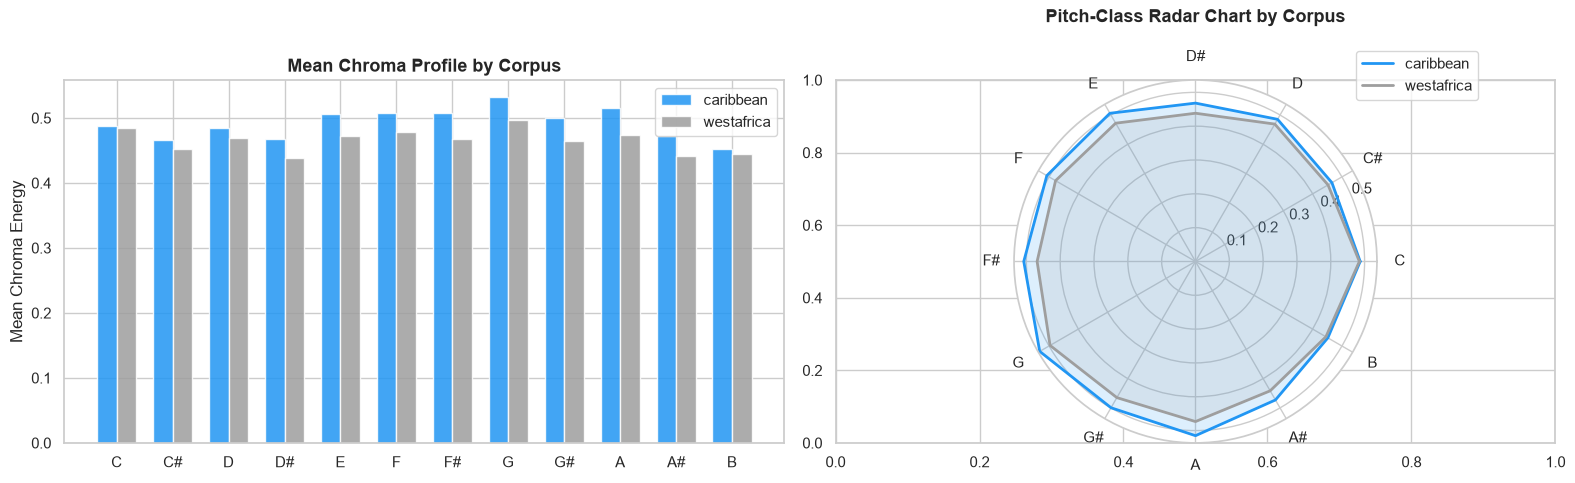

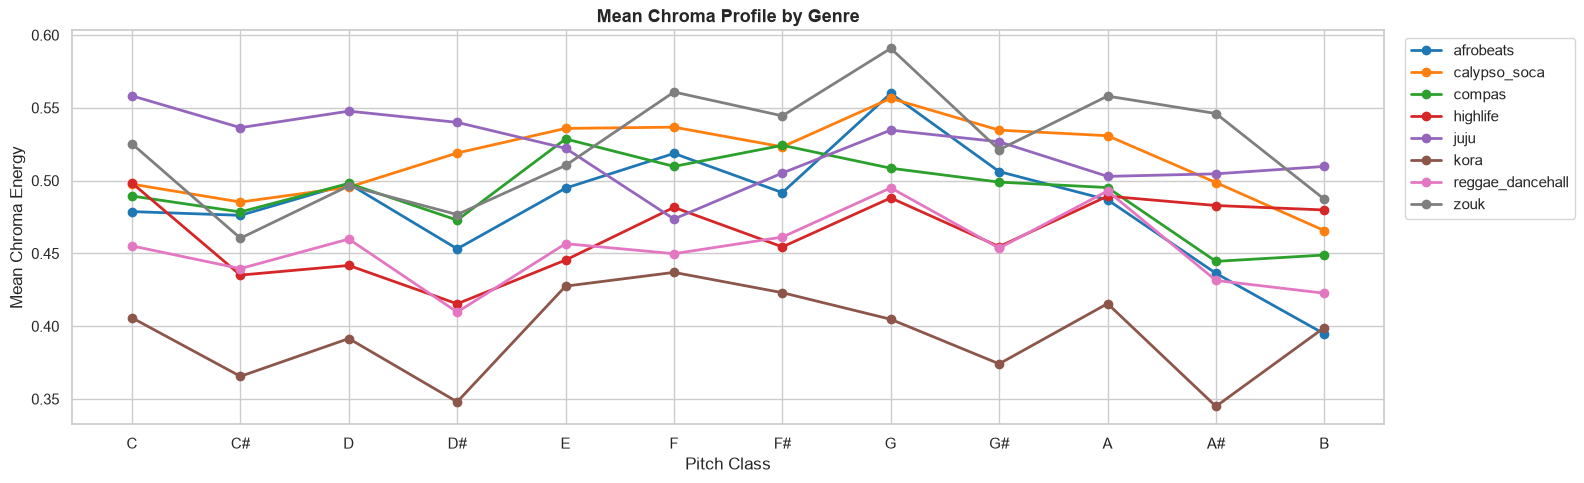

In [103]:
chroma_cols = [f"chroma_{pc}" for pc in PITCH_CLASSES if f"chroma_{pc}" in df.columns]

if not chroma_cols:
    print("No chroma columns found. Make sure chroma_mean was extracted and unpacked.")
else:
    # ── Mean chroma profile per corpus ───────────────────────────────────────────
    chroma_corpus = df.groupby("corpus")[chroma_cols].mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar chart — side by side for direct comparison
    x = np.arange(len(PITCH_CLASSES))
    width = 0.35
    corpora = chroma_corpus.index.tolist()
    colors = [CORPUS_PALETTE.get(c, "#9E9E9E") for c in corpora]

    for k, (corpus_name, color) in enumerate(zip(corpora, colors)):
        vals = chroma_corpus.loc[corpus_name].values
        axes[0].bar(x + k * width, vals, width, label=corpus_name, color=color, alpha=0.85)

    axes[0].set_xticks(x + width / 2)
    axes[0].set_xticklabels(PITCH_CLASSES)
    axes[0].set_title("Mean Chroma Profile by Corpus", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Mean Chroma Energy")
    axes[0].legend()

    # Radar / spider chart
    N = len(PITCH_CLASSES)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    ax_radar = plt.subplot(122, polar=True)
    for corpus_name, color in zip(corpora, colors):
        vals = chroma_corpus.loc[corpus_name].values.tolist()
        vals += vals[:1]  # close the loop
        ax_radar.plot(angles, vals, color=color, linewidth=2, label=corpus_name)
        ax_radar.fill(angles, vals, color=color, alpha=0.15)

    ax_radar.set_thetagrids(np.degrees(angles[:-1]), PITCH_CLASSES)
    ax_radar.set_title("Pitch-Class Radar Chart by Corpus",
                       fontsize=13, fontweight="bold", pad=20)
    ax_radar.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.show()

    # ── Per-genre chroma bar chart ────────────────────────────────────────────
    chroma_genre = df.groupby("genre")[chroma_cols].mean()

    plt.figure(figsize=(16, 5))
    for j, genre_name in enumerate(chroma_genre.index):
        plt.plot(PITCH_CLASSES, chroma_genre.loc[genre_name].values,
                 marker="o", label=genre_name, color=GENRE_PALETTE[j], linewidth=2)

    plt.title("Mean Chroma Profile by Genre", fontsize=13, fontweight="bold")
    plt.xlabel("Pitch Class")
    plt.ylabel("Mean Chroma Energy")
    plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 10. Correlation Matrices — Pearson and Spearman

**Pearson** captures linear co-variation. **Spearman** captures rank-based co-variation (more robust to outliers). Computing both lets us flag features that appear related only because of a few extreme tracks (Pearson high, Spearman low) vs genuinely co-varying features (both high).

Highly correlated features are redundant — you may not need both in a model.

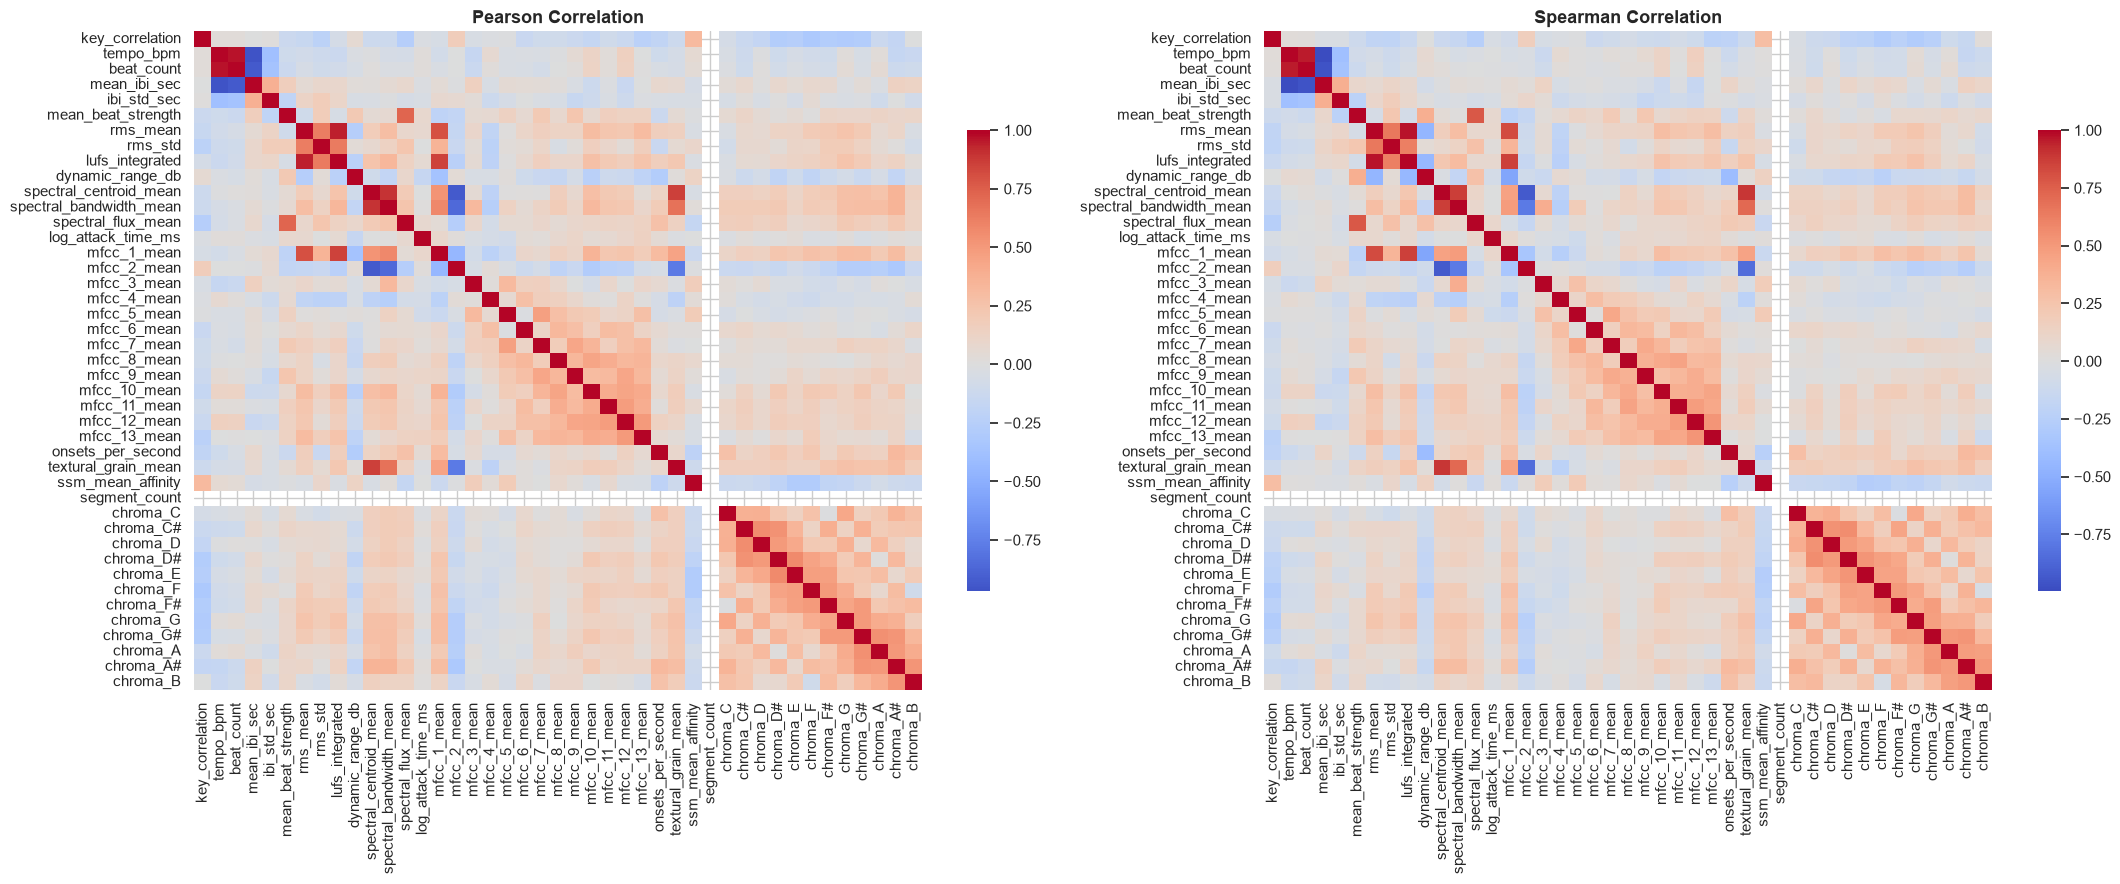

In [104]:
pearson_corr = df[numeric_cols].corr(method="pearson")
spearman_corr = df[numeric_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0, ax=axes[0],
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.7})
axes[0].set_title("Pearson Correlation", fontsize=13, fontweight="bold")

sns.heatmap(spearman_corr, cmap="coolwarm", center=0, ax=axes[1],
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.7})
axes[1].set_title("Spearman Correlation", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

In [105]:
# ── List pairs with |r| above threshold — these are candidates for redundancy removal ──
CORR_THRESHOLD = 0.85

def list_high_correlations(corr_matrix, threshold):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({"feature_1": cols[i], "feature_2": cols[j], "correlation": r})
    return pd.DataFrame(pairs).sort_values("correlation", ascending=False)

high_pearson = list_high_correlations(pearson_corr, CORR_THRESHOLD)
print(f"{len(high_pearson)} feature pairs with |Pearson r| >= {CORR_THRESHOLD}")
print("These are candidates for removal before modeling (keep only one from each pair):")
display(high_pearson)

8 feature pairs with |Pearson r| >= 0.85
These are candidates for removal before modeling (keep only one from each pair):


,feature_1,feature_2,correlation
0,tempo_bpm,beat_count,0.962651
3,rms_mean,lufs_integrated,0.941265
4,spectral_centroid_mean,spectral_bandwidth_mean,0.895105
6,spectral_centroid_mean,textural_grain_mean,0.856272
7,spectral_bandwidth_mean,mfcc_2_mean,-0.854534
5,spectral_centroid_mean,mfcc_2_mean,-0.934177
2,beat_count,mean_ibi_sec,-0.935648
1,tempo_bpm,mean_ibi_sec,-0.968189


## 11. Group-Profile Heatmaps

A compact view of how every group's *mean* feature values compare, all at once. Because features are on very different scales (BPM vs LUFS vs MFCC coefficients), we **z-score** each feature column before plotting — so the colour reflects relative position within each feature's distribution, not raw units.

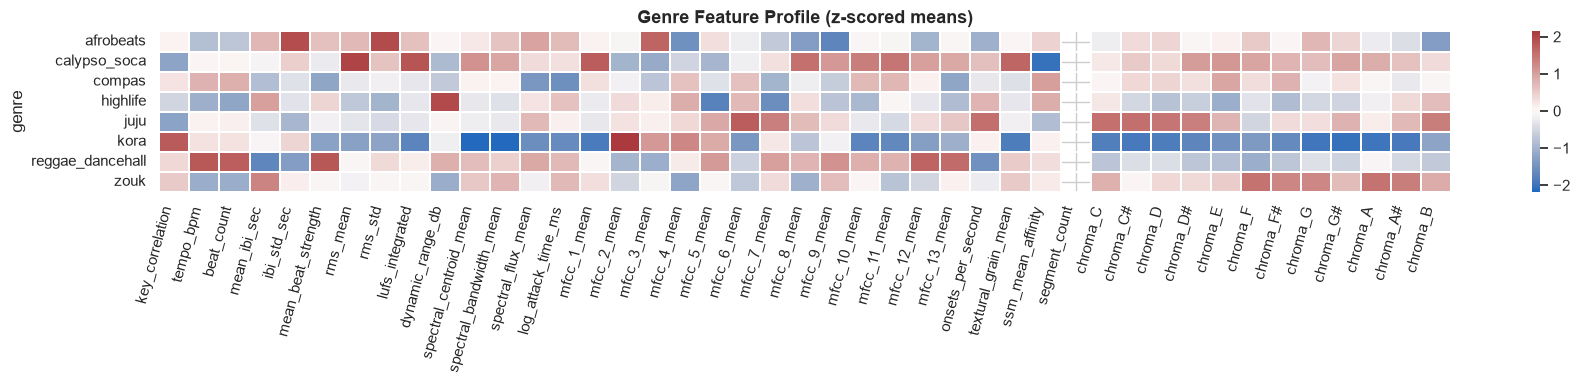

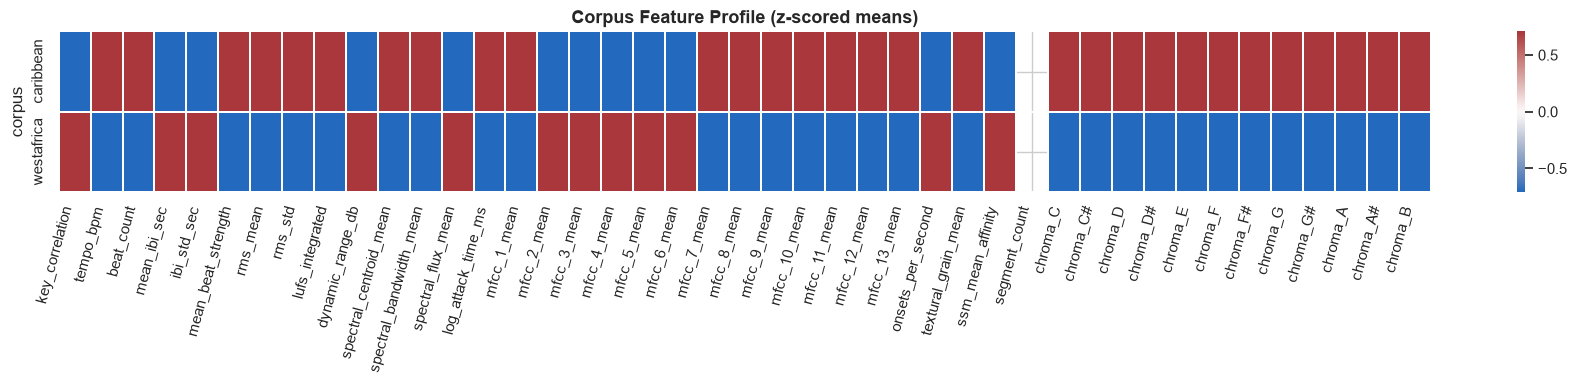

In [106]:
def group_mean_heatmap(df, group_col, feature_cols, title):
    group_means = df.groupby(group_col)[feature_cols].mean()
    z = (group_means - group_means.mean()) / group_means.std()

    plt.figure(figsize=(18, max(4, 0.5 * len(group_means))))
    sns.heatmap(z, cmap="vlag", center=0, xticklabels=True, yticklabels=True,
                linewidths=0.3, annot=(len(feature_cols) <= 15))
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

group_mean_heatmap(df, "genre", numeric_cols, "Genre Feature Profile (z-scored means)")
group_mean_heatmap(df, "corpus", numeric_cols, "Corpus Feature Profile (z-scored means)")

## 12.  PCA Visualization — Do Tracks Cluster by Tradition?

**Principal Component Analysis (PCA)** reduces all your features (could be 30+) down to 2 dimensions while preserving as much variance as possible. Then we plot every track as a dot, coloured by corpus.

**What to look for:**
- If Caribbean (blue) and West African (orange) dots form **separate clusters** → the acoustic features successfully separate the two traditions.
- If the dots are **mixed together** → the traditions share a lot acoustically, and a simple classifier would struggle.
- If Caribbean genres form **sub-clusters within the Caribbean blob** → individual genres are acoustically distinct from each other.

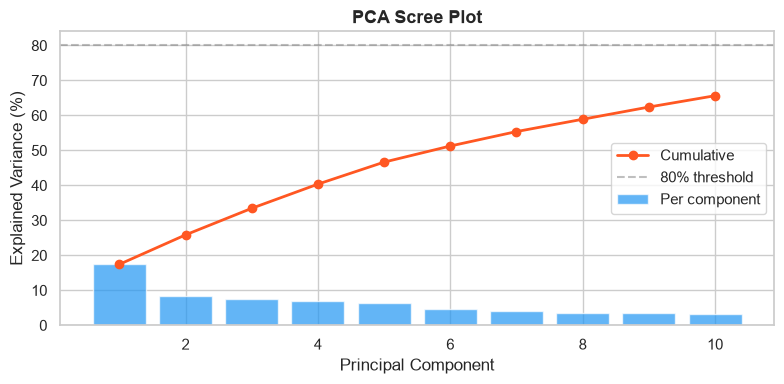

PC1 explains 17.4% of variance
PC2 explains 8.4% of variance
First 2 PCs together explain 25.8% of total variance
1 components needed to explain 80% of variance


In [107]:
# ── Step 1: Standardize features (PCA requires zero mean, unit variance) ──────
X = df[numeric_cols].fillna(df[numeric_cols].median())  # fill any remaining NaNs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Step 2: Fit PCA ───────────────────────────────────────────────────────────
pca = PCA(n_components=10, random_state=42)  # keep 10 components first for scree plot
X_pca = pca.fit_transform(X_scaled)

# ── Scree plot: how much variance does each component explain? ────────────────
explained = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained)+1), explained, color="#2196F3", alpha=0.7, label="Per component")
ax.plot(range(1, len(explained)+1), cumulative, color="#FF5722", marker="o",
        linewidth=2, label="Cumulative")
ax.axhline(80, color="gray", linestyle="--", alpha=0.5, label="80% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance (%)")
ax.set_title("PCA Scree Plot", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

n_for_80pct = np.argmax(cumulative >= 80) + 1
print(f"PC1 explains {explained[0]:.1f}% of variance")
print(f"PC2 explains {explained[1]:.1f}% of variance")
print(f"First 2 PCs together explain {cumulative[1]:.1f}% of total variance")
print(f"{n_for_80pct} components needed to explain 80% of variance")

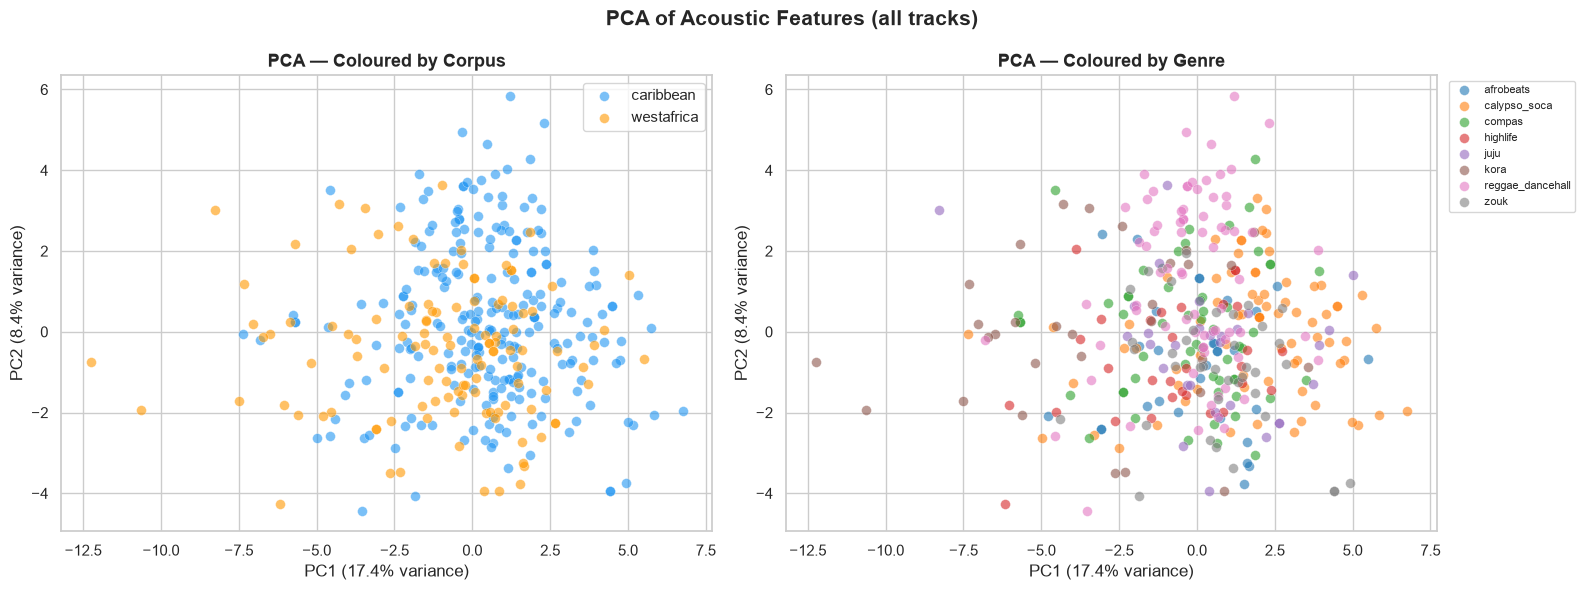

In [122]:
# ── Step 3: 2D scatter plot coloured by corpus ────────────────────────────────
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "corpus": df["corpus"].values,
    "genre": df["genre"].values
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: coloured by corpus
for corpus_name, color in CORPUS_PALETTE.items():
    sub = pca_df[pca_df["corpus"] == corpus_name]
    axes[0].scatter(sub["PC1"], sub["PC2"], c=color, label=corpus_name,
                    alpha=0.6, s=50, edgecolors="white", linewidths=0.3)

axes[0].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[0].set_title("PCA — Coloured by Corpus", fontsize=13, fontweight="bold")
axes[0].legend()

# Plot 2: coloured by genre
genres = pca_df["genre"].unique()
for j, genre_name in enumerate(sorted(genres)):
    sub = pca_df[pca_df["genre"] == genre_name]
    axes[1].scatter(sub["PC1"], sub["PC2"], c=[GENRE_PALETTE[j]], label=genre_name,
                    alpha=0.6, s=50, edgecolors="white", linewidths=0.3)

axes[1].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[1].set_title("PCA — Coloured by Genre", fontsize=13, fontweight="bold")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.suptitle("PCA of Acoustic Features (all tracks)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

In [109]:
# ── Step 4: PCA Loadings — which original features drive PC1 and PC2? ─────────
# Loadings tell you which features are most responsible for the separation you see
loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Show top 10 features driving PC1 and PC2
for pc in ["PC1", "PC2"]:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f"\nTop 10 features loading onto {pc}:")
    print(top.round(3).to_string())


Top 10 features loading onto PC1:
spectral_bandwidth_mean    0.263
mfcc_1_mean                0.261
spectral_centroid_mean     0.247
mfcc_2_mean                0.239
textural_grain_mean        0.219
chroma_G#                  0.216
chroma_A#                  0.211
chroma_G                   0.209
lufs_integrated            0.202
rms_mean                   0.199

Top 10 features loading onto PC2:
tempo_bpm       0.371
mean_ibi_sec    0.359
beat_count      0.355
mfcc_12_mean    0.264
mfcc_10_mean    0.246
mfcc_9_mean     0.223
mfcc_13_mean    0.219
mfcc_8_mean     0.217
ibi_std_sec     0.201
mfcc_11_mean    0.199


## 13. Feature Separability Ranking — Cohen's d

**Cohen's d** measures the *effect size* of the difference between two groups for a given feature. Unlike a p-value (which only tells you *whether* there's a difference), Cohen's d tells you *how big* that difference is.

| d value | Interpretation |
|---------|----------------|
| 0.0 – 0.2 | Negligible |
| 0.2 – 0.5 | Small |
| 0.5 – 0.8 | Medium |
| > 0.8 | Large |

The top-ranked features by Cohen's d are your most important findings.

In [110]:
def cohen_d(group1_vals, group2_vals):
    """
    Cohen's d = (mean1 - mean2) / pooled_std
    Positive d = group1 has higher mean. Negative = group2 higher.
    """
    n1, n2 = len(group1_vals), len(group2_vals)
    if n1 < 2 or n2 < 2:
        return np.nan
    mean_diff = group1_vals.mean() - group2_vals.mean()
    # Pooled standard deviation
    pooled_std = np.sqrt(
        ((n1 - 1) * group1_vals.std()**2 + (n2 - 1) * group2_vals.std()**2)
        / (n1 + n2 - 2)
    )
    return mean_diff / pooled_std if pooled_std > 0 else 0.0

# Get the two corpus groups
corpus_names = df["corpus"].unique()
if len(corpus_names) != 2:
    print(f"Found {len(corpus_names)} corpus values: {corpus_names}. Need exactly 2.")
else:
    g1_name, g2_name = corpus_names[0], corpus_names[1]
    g1 = df[df["corpus"] == g1_name]
    g2 = df[df["corpus"] == g2_name]

    effect_sizes = []
    for col in numeric_cols:
        vals1 = g1[col].dropna()
        vals2 = g2[col].dropna()
        d = cohen_d(vals1, vals2)
        effect_sizes.append({
            "feature": col,
            "cohens_d": d,
            "abs_d": abs(d),
            "direction": f"{g1_name} higher" if d > 0 else f"{g2_name} higher",
            "magnitude": "large" if abs(d) >= 0.8 else
                         "medium" if abs(d) >= 0.5 else
                         "small" if abs(d) >= 0.2 else "negligible"
        })

    effect_df = pd.DataFrame(effect_sizes).sort_values("abs_d", ascending=False)

    print(f"Feature separability: Caribbean ({g1_name}) vs West African ({g2_name})")
    print(f"\nLarge effect features (|d| >= 0.8) — MOST separating:")
    display(effect_df[effect_df["magnitude"] == "large"][["feature", "cohens_d", "direction"]].head(15))

    print(f"\nMedium effect features (0.5 <= |d| < 0.8):")
    display(effect_df[effect_df["magnitude"] == "medium"][["feature", "cohens_d", "direction"]].head(10))

Feature separability: Caribbean (caribbean) vs West African (westafrica)

Large effect features (|d| >= 0.8) — MOST separating:


,feature,cohens_d,direction



Medium effect features (0.5 <= |d| < 0.8):


,feature,cohens_d,direction
15,mfcc_2_mean,-0.708081,westafrica higher
10,spectral_centroid_mean,0.647366,caribbean higher
14,mfcc_1_mean,0.553455,caribbean higher
28,textural_grain_mean,0.520996,caribbean higher


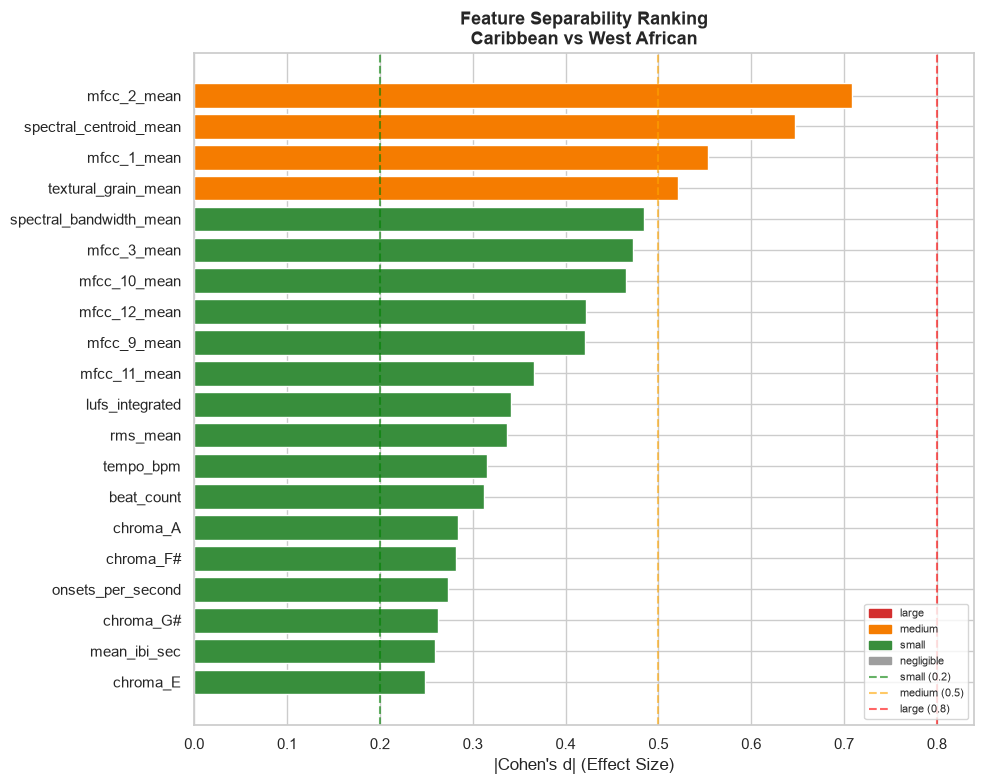


→ These top features are your strongest analytical findings.
  They should anchor your statistical tests (Section 04) and your
  discussion of ethnomusicological significance.


In [111]:
# ── Visualize: ranked bar chart of |Cohen's d| for top 20 features ────────────
top20 = effect_df.head(20).copy()

# Colour by magnitude
mag_colors = {
    "large": "#D32F2F",    # red
    "medium": "#F57C00",   # orange
    "small": "#388E3C",    # green
    "negligible": "#9E9E9E"  # grey
}

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top20["feature"][::-1],
    top20["abs_d"][::-1],
    color=[mag_colors[m] for m in top20["magnitude"][::-1]]
)

# Reference lines
ax.axvline(0.2, color="green", linestyle="--", alpha=0.6, label="small (0.2)")
ax.axvline(0.5, color="orange", linestyle="--", alpha=0.6, label="medium (0.5)")
ax.axvline(0.8, color="red", linestyle="--", alpha=0.6, label="large (0.8)")

ax.set_xlabel("|Cohen's d| (Effect Size)")
ax.set_title(f"Feature Separability Ranking\nCaribbean vs West African",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower right")

# Add legend for magnitude colours
patches = [mpatches.Patch(color=c, label=m) for m, c in mag_colors.items()]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0],
          loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

print("\n→ These top features are your strongest analytical findings.")
print("  They should anchor your statistical tests (Section 04) and your")
print("  discussion of ethnomusicological significance.")

## 14. Remove Near-Zero-Variance Features

Features with near-zero variance carry almost no information to distinguish tracks or groups, and can cause numerical issues in some models. We flag any feature whose **coefficient of variation** (std / |mean|) falls below a small threshold, or whose raw variance is effectively zero.

In [112]:
VARIANCE_THRESHOLD = 1e-6
CV_THRESHOLD = 0.01

variances = df[numeric_cols].var()
means = df[numeric_cols].mean()
cv = variances.pow(0.5) / means.abs().replace(0, np.nan)

near_zero_variance = variances[variances < VARIANCE_THRESHOLD].index.tolist()
near_zero_cv = cv[(cv < CV_THRESHOLD) & cv.notna()].index.tolist()

low_variance_features = sorted(set(near_zero_variance) | set(near_zero_cv))

print(f"Flagged {len(low_variance_features)} near-zero-variance features:")
print(low_variance_features)

Flagged 1 near-zero-variance features:
['segment_count']


In [113]:
clean_df = df.drop(columns=low_variance_features)
clean_numeric_cols = [c for c in numeric_cols if c not in low_variance_features]

print(f"Kept {len(clean_numeric_cols)} of {len(numeric_cols)} numeric features.")

OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset for the next notebook (statistical tests)
clean_path = OUT_DIR / "features_eda_clean.csv"
clean_df.to_csv(clean_path, index=False)

# Save the normality test results — the next notebook needs to know which
# tests to use per feature
normality_path = OUT_DIR / "normality_test_results.csv"
normality_df.to_csv(normality_path, index=False)

# Save the effect size ranking — key output for your research findings
effect_path = OUT_DIR / "feature_effect_sizes.csv"
effect_df.to_csv(effect_path, index=False)

# Log dropped features
log_path = OUT_DIR / "dropped_features.txt"
with open(log_path, "w") as f:
    f.write("Features dropped for near-zero variance:\n")
    for feat in low_variance_features:
        f.write(f"- {feat} (variance={variances.get(feat, float('nan')):.6g})\n")

print(f"\nSaved:")
print(f"  {clean_path} — clean features for Section 04")
print(f"  {normality_path} — tells Section 04 which tests to use")
print(f"  {effect_path} — Cohen's d rankings (your key EDA finding)")
print(f"  {log_path} — log of dropped features")

Kept 42 of 43 numeric features.

Saved:
  ../data/processed/features_eda_clean.csv — clean features for Section 04
  ../data/processed/normality_test_results.csv — tells Section 04 which tests to use
  ../data/processed/feature_effect_sizes.csv — Cohen's d rankings (your key EDA finding)
  ../data/processed/dropped_features.txt — log of dropped features
